# Protecto 1 parte 4

**Proyecto 1 parte 3**
Se indica que continuemos con la parte 3 decidi copiar la informacion ya que puede que realice algun cambio y/o mejora.

En esta parte comenzamos a revisar y explorar la informacion del DataFrame utilizando las operaciones basicas como Head, Tail, Info, Describe y Types. 

Ademas utilizamos funciones de filtros para visualizar la informacion inicialmente.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/carlis/retail-sales-analysis/data/retail_sales_dataset.csv")

print("Primeras filas del DataFrame:")
print(df.head(10))

print("Ultimas filas del DataFrame:")
print(df.tail(5))

print("Informacion del DataFrame:")
print(df.info())

print("Estadisticas descriptivas del DataFrame:")
print(df.describe())

print("Tipos de datos de las Columnas")
print(df.dtypes)

print("Conteo de valores unicos en la columna 'Product Category':")
print(df['Product Category'].value_counts())

print("Valores unicos en la columna 'Gender':")
print(df['Gender'].unique())

#Filtrado de datos
filtro_ventas = df[df['Total Amount'] > 500]
print(filtro_ventas)

filtro_precio = df[df['Price per Unit'] < 50]
print(filtro_precio)

filtro_query = df.query("`Product Category` == 'Clothing' and `Total Amount` > 30")
print(filtro_query)

#Slicing de datos
df_columnas = df[["Product Category", "Total Amount"]]
print(df_columnas)

df_loc = df.loc[5:10, ["Product Category", "Customer ID"]]
print(df_loc)

df_iloc = df.iloc[0:5, 0:3]
print(df_iloc)

Primeras filas del DataFrame:
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   
5               6  2023-04-25     CUST006  Female   45           Beauty   
6               7  2023-03-13     CUST007    Male   46         Clothing   
7               8  2023-02-22     CUST008    Male   30      Electronics   
8               9  2023-12-13     CUST009    Male   63      Electronics   
9              10  2023-10-07     CUST010  Female   52         Clothing   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1 

**Limpieza de datos**

Antes de continuar con lo solicitado en la parte 3 de este proyecto, debemos hacer una limpieza de datos con el fin de realizar el analisis de estos y determinar que informacion sera de mayor utilidad.

1.Para la limpieza de datos primero es necesario identificar si tenemos datos nulos, es este caso no contamos con nulos.

2.Se debe corregir tipos, en este caso considero que es necesario corregir la columna Date que se encuentra en str a datatime ya que esto nos ayuda a un mejor manejo de la informacion de esta columna.

3.Como ultimo punto es necesario revisar si tenemos filas duplicadas.

Para este caso no tenemos nulos, duplicados y ya realizamos el cambio de tipos por lo tanto podemos continuar con el analisis de la informacion.

In [2]:
print("Verificacion de datos nulos:")
print(df.isnull().sum())

Verificacion de datos nulos:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [3]:
df['Date'] = df['Date'].astype('datetime64[us]')
print("Fecha convertida:")
print(df[['Date']].dtypes)

Fecha convertida:
Date    datetime64[us]
dtype: object


In [4]:
n_duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {n_duplicados}")

Filas duplicadas: 0


Para cerrar la limpieza de datos verifico la existencia de valores faltantes mediante isnull().sum().sum(), obteniendo como resultado 0, lo que confirma que el dataset no presenta datos nulos y por lo tanto no es necesario aplicar tecnicas de imputacion.

In [5]:
df.isnull().sum().sum()

np.int64(0)

**Transformacion de datos**

1.Crear nuevas columnas, ya que el dataset es bastante completo se decide realizar una comprobacion del valor total para verificar si los montos son correctos y con esto podriamos tambien calcular un promedio por unidad.

2.Normalizar, se realiza la normalizacion del total para escalar los valores en un rango especifico.

3.Clasificar datos, se considera realizar una clasificacion de las ventas, si el total es mayor a 800 se considera venta alta, si el valor es mayor o igual a 400 es venta media y para lo demas se considera venta baja, pensando que si en algun momento se quiere evaluar las ventas se pueda tener una rapida visualizacion.

In [6]:
#Comprobacion valor neto
df['Comprobacion_valor_total'] = df['Price per Unit'] * df['Quantity']
print("Nueva Columna:")
df[['Total Amount', 'Comprobacion_valor_total']].head()

Nueva Columna:


,Total Amount,Comprobacion_valor_total
0,150,150
1,1000,1000
2,30,30
3,500,500
4,100,100


In [7]:
#Venta promedio por unidad
df['promedio_unidad'] = df['Total Amount'] / df['Quantity']
print('Promedio por unidad:')
df[['Comprobacion_valor_total', 'promedio_unidad']].head()

Promedio por unidad:


,Comprobacion_valor_total,promedio_unidad
0,150,50.0
1,1000,500.0
2,30,30.0
3,500,500.0
4,100,50.0


In [8]:
#normalizar columna total
max_value = df['Total Amount'].max()
min_value = df['Total Amount'].min()
df['Total_normalizado'] = df['Total Amount'].apply(lambda x: (x - min_value)/(max_value - min_value))
print("Nueva columna 'Total_normalizado':")
df[['Total Amount', 'Total_normalizado']].head()

Nueva columna 'Total_normalizado':


,Total Amount,Total_normalizado
0,150,0.063291
1,1000,0.493671
2,30,0.002532
3,500,0.240506
4,100,0.037975


In [9]:
#Clasificar datos
def clasificar_venta (Total):
    if Total >= 800:
        return "Alta"
    elif Total >= 400:
        return "Media"
    else:
        return "Baja"

df['Clasificacion'] = df['Total Amount'].apply(clasificar_venta)
print('Clasificacion:')
df[['Total Amount', 'Clasificacion']].head()

Clasificacion:


,Total Amount,Clasificacion
0,150,Baja
1,1000,Alta
2,30,Baja
3,500,Media
4,100,Baja


**Agrupacion y agregacion**

1.Primero realizaremos agrupaciones de datos con groupby donde podremos organizar la informacion por categorias especificas como por ejemplo ver total de ventas por categoria de producto, total de ventas por genero y cantidad de ventas por genero, esto con el fin de ver las categorias de productos que tienen mayores ingresos y tambien determinar si hay una brecha alta entre compras entre hombres y mujeres.

2.Por ultimo utilizaremos la funcion de agregacion y podremos ver un detalle estadistico de la informacion por genero con suma de sus ventas, un promedio y la cantidad  de ventas. Ademas realizaremos un resumen por categoria de producto, es decir suma de productos, promedio, cantidad, minimo, maximo, desviacion estandar, varianza de los valores y un resumen de categoria de productos por edad con un promedio, minimo y maximo. Esta informacion nos puede ayudar a identificar que categorias de productos tienen mayores ventas, si hay mucha diferencia entre compras de hombre y mujeres y los rangos estareos de quienes compran.

In [10]:
#Agrupaciones con Groupby
ventas_por_categoria_producto = df.groupby('Product Category')['Total Amount'].sum()
print("Ventas por categoria de producto:")
print(ventas_por_categoria_producto)


ventas_por_genero = df.groupby('Gender')['Total Amount'].sum()
print("Ventas por genero:")
print(ventas_por_genero)

grouped = df.groupby('Gender')
cantidad_ventas_genero = grouped['Total Amount'].count()
print('Cantidad de ventas por genero:')
print(cantidad_ventas_genero)

Ventas por categoria de producto:
Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64
Ventas por genero:
Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64
Cantidad de ventas por genero:
Gender
Female    510
Male      490
Name: Total Amount, dtype: int64


In [11]:
#Funcion de agregacion
agregacion_genero = df.groupby('Gender')['Total Amount'].agg(['sum', 'mean', 'count'])
print("Resumen por genero:")
print(agregacion_genero)

agregacion_producto = df.groupby('Product Category')['Quantity'].agg(['sum', 'mean', 'count', 'min', 'max','std','var'])
print("Resumen por producto:")
print(agregacion_producto)

agregacion_edad = df.groupby('Product Category')['Age'].agg(['mean', 'min', 'max'])
print("Resumen por edad:")
print(agregacion_edad)


Resumen por genero:
           sum        mean  count
Gender                           
Female  232840  456.549020    510
Male    223160  455.428571    490
Resumen por producto:
                  sum      mean  count  min  max       std       var
Product Category                                                    
Beauty            771  2.511401    307    1    4  1.100668  1.211471
Clothing          894  2.547009    351    1    4  1.142647  1.305641
Electronics       849  2.482456    342    1    4  1.153084  1.329603
Resumen por edad:
                       mean  min  max
Product Category                     
Beauty            40.371336   18   64
Clothing          41.948718   18   64
Electronics       41.736842   18   64


**Analisis personalizado con Apply**

1.Funcion personalizada, utilice un calculo simple para obtener el porcetaje de ventas por genero, con el fin de continuar analizando este campo y poder determinar que genero realiza mas compras.

In [12]:
total_global = df['Total Amount'].sum()

porcentaje_genero = ventas_por_genero.apply(lambda x: (x / total_global) * 100)
print('Porcentaje de ventas por genero:')
print(porcentaje_genero)

Porcentaje de ventas por genero:
Gender
Female    51.061404
Male      48.938596
Name: Total Amount, dtype: float64


2.Funcion de uso avanzado, para este caso se intento realizar un ejercicio parecido a uno indicado en los apuntes entregados, pero esto me dio un error, se consulto con chat gpt a que correspondia el error y señalo apply funcionaba bien cuando se necesita logica personalizada fila a fila y que Pandas trabaja mejor para casos entre columnas y serie sin apply por eso se realizo un ejercicio sin usar esta opcion, es por esto que utilice una funcion mas basica igualmente al inicio al realizar la "formula" se uso solo el .mean y me indico como desviacion NaN, por lo tanto se consulto con chat Gpt por que ocurria esto y señalo que al usar .mean no se aplica el calculo de promedio a cada elemento de un grupo es por esto que se utilizo transform y al ejecutar creo que funciono.


import numpy as np

promedio_categoria = df.groupby('Product Category')['Total Amount'].mean()
df['Desviacion'] = df['Total Amount'].apply(lambda x: np.abs(x - promedio_categoria))
print(df[['Product Category', 'Total Amount', 'Desviacion']].head())

In [13]:
promedio_categoria = df.groupby('Product Category')['Total Amount'].transform('mean')

df['Desviacion'] = df['Total Amount'] - promedio_categoria

print(df[['Product Category', 'Total Amount', 'Desviacion']].head())

  Product Category  Total Amount  Desviacion
0           Beauty           150 -317.475570
1         Clothing          1000  556.752137
2      Electronics            30 -428.786550
3         Clothing           500   56.752137
4           Beauty           100 -367.475570


**Distribucion de variables numericas**


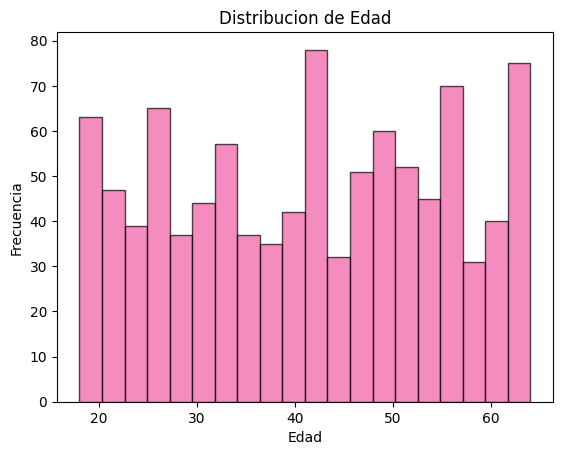

In [14]:
plt.hist(df['Age'], bins=20, color='#F05BA6', edgecolor='black', alpha=0.7)
plt.title('Distribucion de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

El Histograma de la variable Age permite observar la distribucion de edades de los clientes. La mayor concentracion de registros se encuentra en edades intermedias, lo que indica que la mayoria de los compradores pertenece a un rango etario adulto joven o medio. Ademas nos permite identificar si existen grupos de edad con menor participacion dentro de las ventas.

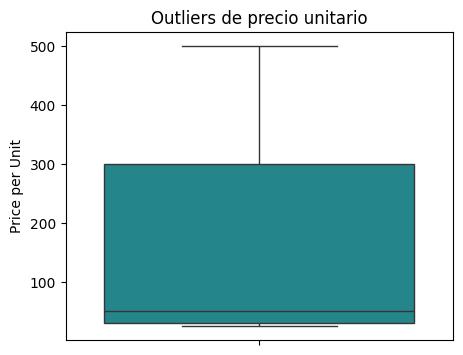

In [15]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df['Price per Unit'], color='#13959C')
plt.title('Outliers de precio unitario')
plt.show()

En el boxplot de la variable precio por unidad permite identificar la distribucion de los precios de los productos y detectar valores atipicos. Se observan algunos valores extremos superiores que indican la existencia de compras significativamente mayores al promedio del conjunto de datos.


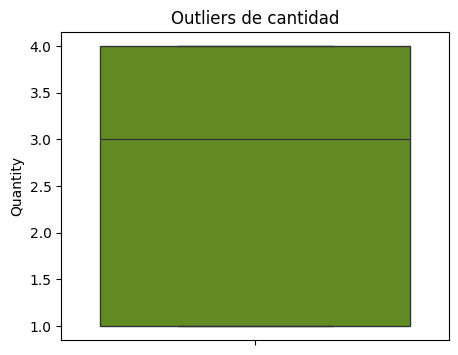

In [16]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df['Quantity'], color='#679C13')
plt.title('Outliers de cantidad')
plt.show()

El boxplot de la variable cantidad permite visualizar la dispersion de las cantidades de productos adquiridos por los clientes, facilitando la identificacion de posibles valores atipicos, correspondientes a compras con cantidades considerablemente superiores o inferiores al comportamiento habitual de los datos.
En este grafico logramos observar una distribucion relativamente homogenea, con pocos valores atipicos.

# Graficos

**Tendencias de ventas a lo largo del tiempo**

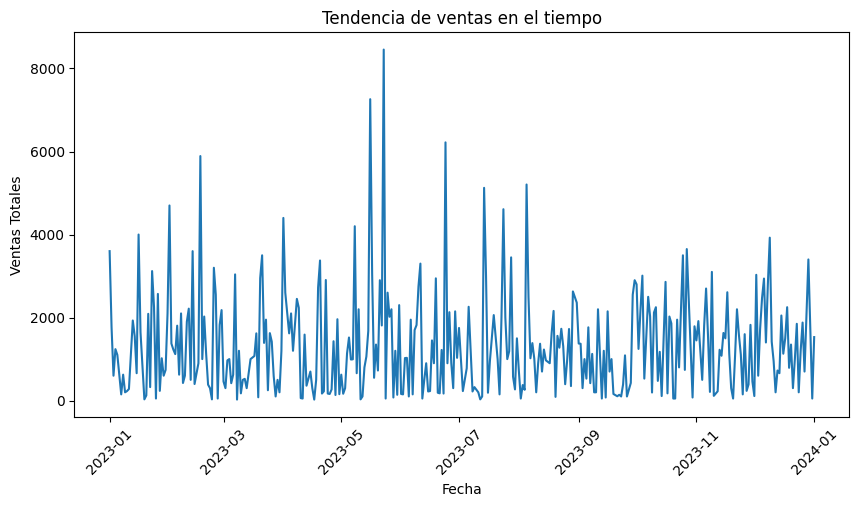

In [17]:
ventas_fecha = df.groupby('Date')['Total Amount'].sum()

plt.figure(figsize=(10,5))
plt.plot(ventas_fecha.index, ventas_fecha.values)
plt.title('Tendencia de ventas en el tiempo')
plt.xlabel('Fecha')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=45)
plt.show()

Este grafico permite observar la evolucion de las ventas a lo largo del tiempo, identificando periodos de mayor actividad comercial y variaciones en el comportamiento de compra. Aca podemos notar un aumento de las ventas entre mayo y julio 2023, ademas visualizamos una mayor baja entre septiembre 2023 y enero 2024.

**Graficos de dispersion**

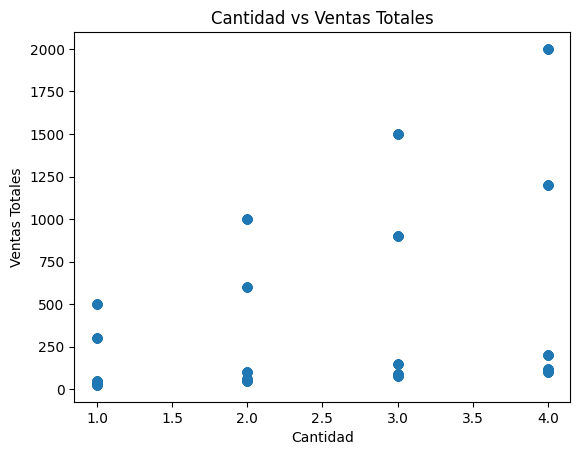

In [18]:
plt.scatter(df['Quantity'], df['Total Amount'])
plt.title('Cantidad vs Ventas Totales')
plt.xlabel('Cantidad')
plt.ylabel('Ventas Totales')
plt.show()

Se observa una relacion positiva entre la cantidad de productos comprados y el monto total de ventas indicando que a mayor cantidad adquirida, mayor es el valor total de la compra.

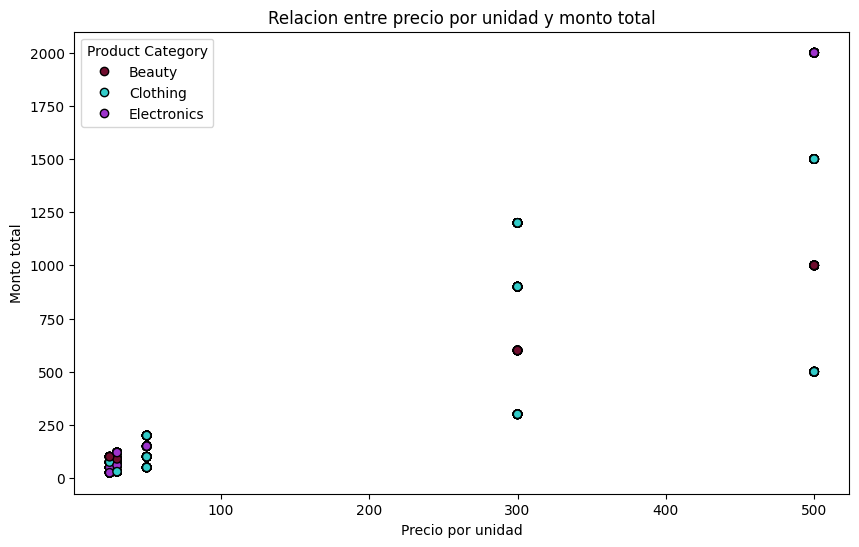

In [22]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Price per Unit', y='Total Amount', hue='Product Category', data=df, palette={'Beauty':'#700D2E', 'Clothing':'#33CCC9', 'Electronics':'#9E33CC'}, edgecolor='black', linewidth=1)
plt.title('Relacion entre precio por unidad y monto total')
plt.xlabel('Precio por unidad')
plt.ylabel('Monto total')
plt.show()

El gráfico muestra una relacion positiva entre precio por unidad y el monto total de compra, indicando que productos con precios mas altos tienden a generar transacciones de mayor valor. Ademas, se observan diferencias entre categorias de productos, evidenciando distintos patrones de consumo según el tipo de articulo adquirido.

**Combinacion Histogramas y boxplots**

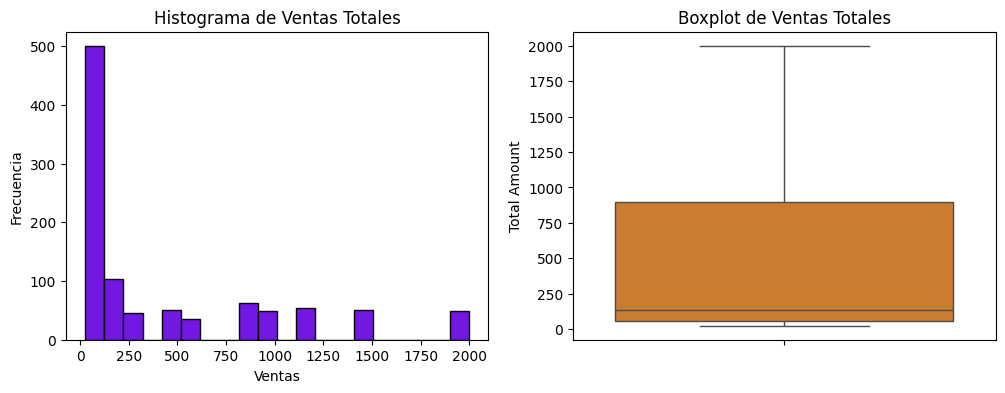

In [35]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(df['Total Amount'], bins=20, color='#7317E3', edgecolor='black')
plt.title('Histograma de Ventas Totales')
plt.xlabel('Ventas')
plt.ylabel('Frecuencia')

plt.subplot(1,2,2)
sns.boxplot(y=df['Total Amount'], color='#E37D17')
plt.title('Boxplot de Ventas Totales')
plt.show()

El histograma muestra una concentracion importante de ventas en rangos medios, mientras que el boxplot evidencia la presencia de valores atipicos superiores, correspondientes a compras significativamente mayores al promedio.